# 🚀 Malaria Detection using YOLOv11x (Zindi Lacuna Challenge)

Welcome! In this notebook, we prepare and train a **YOLOv11x object detection model** to identify malaria parasites from microscopic images 🦟🔬.

In [1]:

WHEELS_DIR = '/kaggle/input/datasets/noob786/ultralytics-offline-package/ultralytics_wheels'

# Install offline using --no-index flag
!pip install --no-index --find-links=$WHEELS_DIR ultralytics

from ultralytics import YOLO
print("✅ Installation successful!")

Looking in links: /kaggle/input/datasets/noob786/ultralytics-offline-package/ultralytics_wheels
Processing /kaggle/input/datasets/noob786/ultralytics-offline-package/ultralytics_wheels/ultralytics-8.4.45-py3-none-any.whl
Processing /kaggle/input/datasets/noob786/ultralytics-offline-package/ultralytics_wheels/ultralytics_thop-2.0.19-py3-none-any.whl (from ultralytics)
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Installation successful!


Copying from /kaggle/input/datasets/rajsahu2004/lacuna-malaria-detection-dataset to /kaggle/working
  Copied file: SampleSubmission.csv
  Copied directory: images
  Copied file: Train.csv
  Copied file: Test.csv
Copy completed
Train annotations: (23530, 7)
Test annotations: (1178, 7)
Unique classes: ['Trophozoite' 'NEG' 'WBC']
Class mapping: {'NEG': 0, 'Trophozoite': 1, 'WBC': 2}
Total unique images: 2747
Training images: 2609
Validation images: 138
Image size: 4032 x 3016
Moving training images and generating labels...


  0%|          | 0/2609 [00:00<?, ?it/s]

Moving validation images and generating labels...


  0%|          | 0/138 [00:00<?, ?it/s]

Copying 1178 test images...


  0%|          | 0/1178 [00:00<?, ?it/s]

Train images: 2609
Train labels: 2609
Val images:   138
Val labels:   138
Test images:  1178
data.yaml saved at /kaggle/working/data.yaml
{'path': '/kaggle/working', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'nc': 3, 'names': ['NEG', 'Trophozoite', 'WBC']}

id_mwq9isyl2m.jpg has 6 boxes


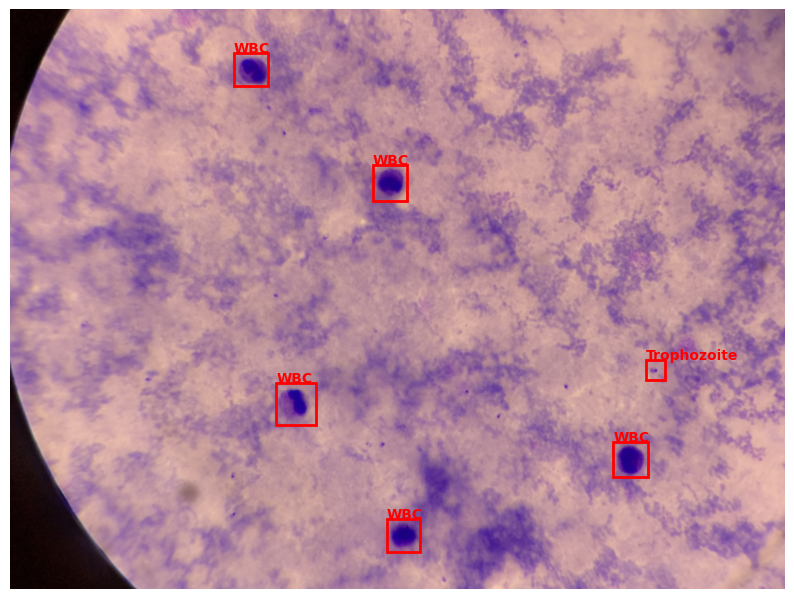


id_58ee05nnpt.jpg has 38 boxes


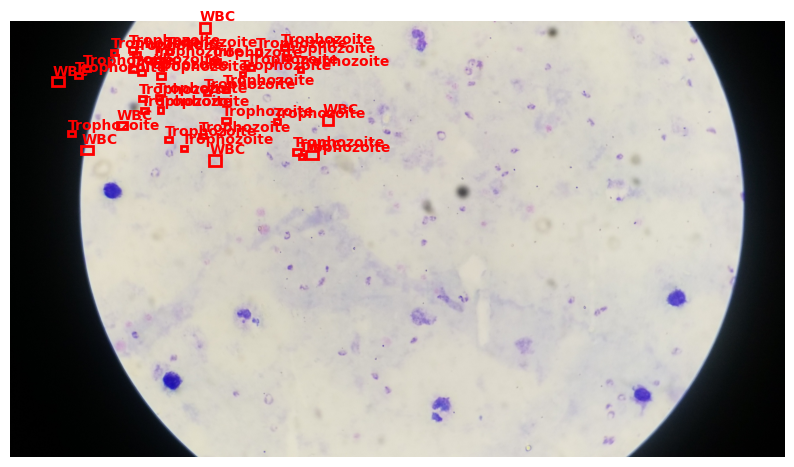


id_4xe7v3uzb0.jpg has 12 boxes


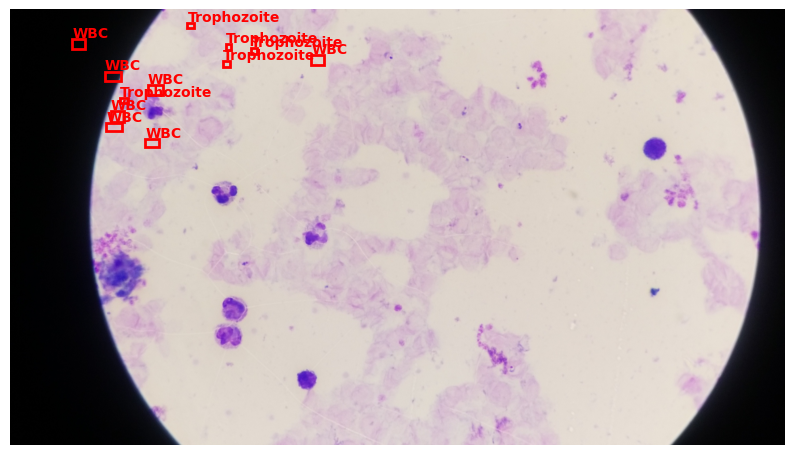


Validation sample: id_fki1jfnxnq.jpg


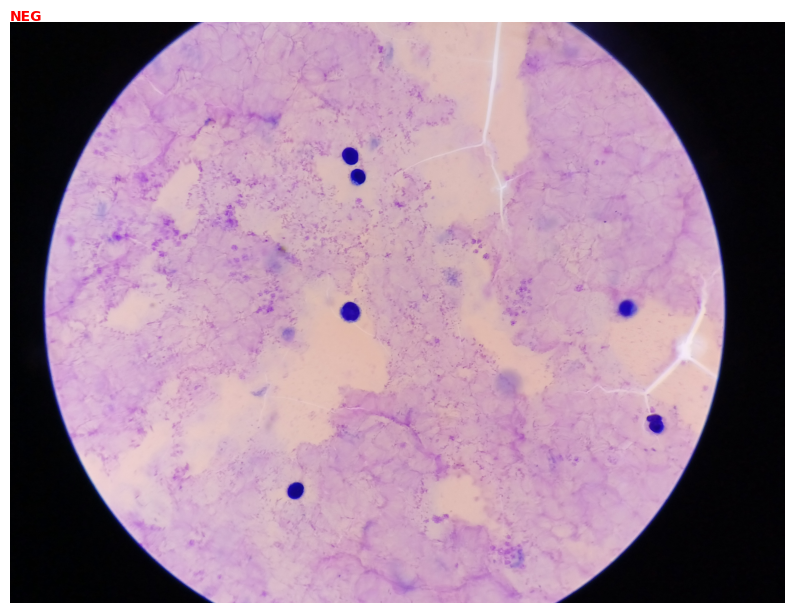


DATASET PREPARATION COMPLETE
Classes: ['NEG', 'Trophozoite', 'WBC']
Number of classes: 3
Training images: 2609
Validation images: 138
Test images: 1178
data.yaml: /kaggle/working/data.yaml


In [2]:
# %% [code]
# Import libraries
import pandas as pd
import os
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import yaml
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# %% [code]
# Copy dataset from input to working directory
def copy_dataset(source_path, destination_path):
    """
    Copy a dataset directory from source to destination.
    """
    try:
        source = Path(source_path)
        dest = Path(destination_path)
        dest.mkdir(parents=True, exist_ok=True)
        
        if not source.exists():
            print(f"Error: Source {source} does not exist")
            return False
            
        print(f"Copying from {source} to {dest}")
        for item in source.iterdir():
            dst_item = dest / item.name
            if item.is_dir():
                if dst_item.exists():
                    shutil.rmtree(dst_item)
                shutil.copytree(item, dst_item)
                print(f"  Copied directory: {item.name}")
            else:
                shutil.copy2(item, dst_item)
                print(f"  Copied file: {item.name}")
        print("Copy completed")
        return True
    except Exception as e:
        print(f"Error: {e}")
        return False

SOURCE_DIR = "/kaggle/input/datasets/rajsahu2004/lacuna-malaria-detection-dataset"
WORK_DIR = Path("/kaggle/working")
copy_dataset(SOURCE_DIR, WORK_DIR)

# %% [code]
# Define working directories
IMAGES_SRC = WORK_DIR / "images"          # all images are here (no subfolders)
LABELS_DIR = WORK_DIR / "labels"          # will be created for YOLO txt files

# YOLO expects:
TRAIN_IMAGES = WORK_DIR / "images/train"
TRAIN_LABELS = WORK_DIR / "labels/train"
VAL_IMAGES   = WORK_DIR / "images/val"
VAL_LABELS   = WORK_DIR / "labels/val"
TEST_IMAGES  = WORK_DIR / "images/test"

for d in [TRAIN_IMAGES, TRAIN_LABELS, VAL_IMAGES, VAL_LABELS, TEST_IMAGES]:
    d.mkdir(parents=True, exist_ok=True)

# %% [code]
# Load CSV annotations
train_anno = pd.read_csv(WORK_DIR / "Train.csv")
test_anno = pd.read_csv(WORK_DIR / "Test.csv")

print(f"Train annotations: {train_anno.shape}")
print(f"Test annotations: {test_anno.shape}")
print(f"Unique classes: {train_anno['class'].unique()}")

# Clean class names
train_anno['class'] = train_anno['class'].str.strip()
class_names = sorted(train_anno['class'].unique())
class_to_id = {name: idx for idx, name in enumerate(class_names)}
print("Class mapping:", class_to_id)

# Add class_id column
train_anno['class_id'] = train_anno['class'].map(class_to_id)

# %% [code]
# Get unique image IDs and split
unique_images = train_anno['Image_ID'].unique()
train_ids, val_ids = train_test_split(unique_images, test_size=0.05, random_state=42)

print(f"Total unique images: {len(unique_images)}")
print(f"Training images: {len(train_ids)}")
print(f"Validation images: {len(val_ids)}")

# %% [code]
def convert_csv_to_yolo(row, img_width, img_height):
    """
    Convert CSV bounding box (xmin, ymin, xmax, ymax) to YOLO format
    (class_id, x_center, y_center, width, height) normalized.
    """
    xmin = row['xmin']
    ymin = row['ymin']
    xmax = row['xmax']
    ymax = row['ymax']
    
    # Calculate center and dimensions
    x_center = (xmin + xmax) / 2.0 / img_width
    y_center = (ymin + ymax) / 2.0 / img_height
    width = (xmax - xmin) / img_width
    height = (ymax - ymin) / img_height
    
    # Clamp values to [0,1]
    x_center = max(0.0, min(1.0, x_center))
    y_center = max(0.0, min(1.0, y_center))
    width = max(0.0, min(1.0, width))
    height = max(0.0, min(1.0, height))
    
    return f"{int(row['class_id'])} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"

# We need image sizes. Assume all images have same size? Let's get from one image.
sample_img = next(IMAGES_SRC.glob("*.jpg"))
if sample_img is None:
    sample_img = next(IMAGES_SRC.glob("*.png"))
with Image.open(sample_img) as img:
    IMG_WIDTH, IMG_HEIGHT = img.size
print(f"Image size: {IMG_WIDTH} x {IMG_HEIGHT}")

# %% [code]
# Generate YOLO label files for training and validation sets
def create_label_file(image_id, image_set, anno_df):
    """Create a .txt label file for a given image_id in the appropriate folder."""
    # Filter annotations for this image
    boxes = anno_df[anno_df['Image_ID'] == image_id]
    if boxes.empty:
        return
    
    # Determine output label path
    if image_id in train_ids:
        label_dir = TRAIN_LABELS
    elif image_id in val_ids:
        label_dir = VAL_LABELS
    else:
        return  # not used
    
    label_path = label_dir / f"{Path(image_id).stem}.txt"
    with open(label_path, 'w') as f:
        for _, row in boxes.iterrows():
            yolo_line = convert_csv_to_yolo(row, IMG_WIDTH, IMG_HEIGHT)
            f.write(yolo_line + "\n")

# First, copy images to train/val folders and generate labels
print("Moving training images and generating labels...")
for img_id in tqdm(train_ids):
    src_img = IMAGES_SRC / img_id
    dst_img = TRAIN_IMAGES / img_id
    if src_img.exists():
        shutil.copy2(src_img, dst_img)
        create_label_file(img_id, 'train', train_anno)
    else:
        print(f"Warning: {src_img} not found")

print("Moving validation images and generating labels...")
for img_id in tqdm(val_ids):
    src_img = IMAGES_SRC / img_id
    dst_img = VAL_IMAGES / img_id
    if src_img.exists():
        shutil.copy2(src_img, dst_img)
        create_label_file(img_id, 'val', train_anno)
    else:
        print(f"Warning: {src_img} not found")

# Copy test images (from Test.csv) to test folder
test_images = test_anno['Image_ID'].unique()
print(f"Copying {len(test_images)} test images...")
for img_id in tqdm(test_images):
    src_img = IMAGES_SRC / img_id
    dst_img = TEST_IMAGES / img_id
    if src_img.exists():
        shutil.copy2(src_img, dst_img)
    else:
        print(f"Warning: test image {src_img} not found")

# %% [code]
# Verify counts
print(f"Train images: {len(list(TRAIN_IMAGES.glob('*')))}")
print(f"Train labels: {len(list(TRAIN_LABELS.glob('*.txt')))}")
print(f"Val images:   {len(list(VAL_IMAGES.glob('*')))}")
print(f"Val labels:   {len(list(VAL_LABELS.glob('*.txt')))}")
print(f"Test images:  {len(list(TEST_IMAGES.glob('*')))}")

# %% [code]
# Create data.yaml for YOLO
data_yaml = {
    'path': str(WORK_DIR.absolute()),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': len(class_names),
    'names': class_names
}

yaml_path = WORK_DIR / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("data.yaml saved at", yaml_path)
print(data_yaml)

# %% [code]
# Function to load YOLO annotations
def load_yolo_labels(label_path, img_shape):
    """Read YOLO txt and return boxes in pixel coordinates."""
    boxes = []
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                class_id, xc, yc, w, h = map(float, parts)
                x1 = (xc - w/2) * img_shape[1]
                y1 = (yc - h/2) * img_shape[0]
                x2 = (xc + w/2) * img_shape[1]
                y2 = (yc + h/2) * img_shape[0]
                boxes.append((int(class_id), x1, y1, x2, y2))
    return boxes

def plot_image_with_boxes(image_path, boxes, class_names):
    img = np.array(Image.open(image_path))
    plt.figure(figsize=(10,10))
    plt.imshow(img)
    for class_id, x1, y1, x2, y2 in boxes:
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='red', facecolor='none', linewidth=2)
        plt.gca().add_patch(rect)
        plt.text(x1, y1-5, class_names[class_id], color='red', fontsize=10, weight='bold')
    plt.axis('off')
    plt.show()

# Show a few training samples
train_img_list = list(TRAIN_IMAGES.glob('*.jpg')) + list(TRAIN_IMAGES.glob('*.png'))
for img_path in train_img_list[:3]:
    label_path = TRAIN_LABELS / (img_path.stem + '.txt')
    if label_path.exists():
        img = np.array(Image.open(img_path))
        boxes = load_yolo_labels(label_path, img.shape)   # <-- FIXED: pass shape correctly
        print(f"\n{img_path.name} has {len(boxes)} boxes")
        plot_image_with_boxes(img_path, boxes, class_names)

# Show a validation sample
val_img_list = list(VAL_IMAGES.glob('*.jpg')) + list(VAL_IMAGES.glob('*.png'))
if val_img_list:
    img_path = val_img_list[0]
    label_path = VAL_LABELS / (img_path.stem + '.txt')
    if label_path.exists():
        img = np.array(Image.open(img_path))
        boxes = load_yolo_labels(label_path, img.shape)   # <-- FIXED
        print(f"\nValidation sample: {img_path.name}")
        plot_image_with_boxes(img_path, boxes, class_names)

# %% [code]
print("\n" + "="*50)
print("DATASET PREPARATION COMPLETE")
print("="*50)
print(f"Classes: {class_names}")
print(f"Number of classes: {len(class_names)}")
print(f"Training images: {len(train_img_list)}")
print(f"Validation images: {len(val_img_list)}")
print(f"Test images: {len(list(TEST_IMAGES.glob('*')))}")
print(f"data.yaml: {yaml_path}")
print("="*50)

In [3]:
import torch
from ultralytics import YOLO

def get_available_devices():
    """Returns list of available GPU devices"""
    if torch.cuda.is_available():
        return list(range(torch.cuda.device_count()))
    else:
        return 'cpu'

# Load model
model = YOLO('/kaggle/input/models/ultralytics/yolo11/pytorch/default/1/yolo11x.pt')

# Get available devices
devices = get_available_devices()
print(f"Using devices: {devices}")

# Calculate appropriate batch size
num_gpus = len(devices) if devices != 'cpu' else 1
batch_per_gpu = 8  # Adjust based on your GPU memory
total_batch = batch_per_gpu * num_gpus

print(f"Number of GPUs: {num_gpus}")
print(f"Total batch size: {total_batch}")

# Train with auto-detected devices
model.train(
    data='data.yaml',
    epochs=60,
    imgsz=960,
    batch=total_batch,
    device=devices,
    patience=8,
    optimizer='AdamW',
    lr0=0.0005,
    lrf=0.005,
    momentum=0.937,
    weight_decay=0.0004,
    warmup_epochs=2,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,
    
    hsv_h=0.01,
    hsv_s=0.6,
    hsv_v=0.3,
    degrees=5.0,
    translate=0.05,
    scale=0.3,
    shear=1.0,
    perspective=0.0005,
    flipud=0.3,
    fliplr=0.5,
    mosaic=0.8,
    mixup=0.05,
    copy_paste=0.05,
    erasing=0.3,
    
    close_mosaic=5,
    overlap_mask=False,
    single_cls=False,
    
    save_period=20,
    seed=42,
    plots=True
)



Using devices: [0, 1, 2, 3]
Number of GPUs: 4
Total batch size: 32
Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
                                                       CUDA:1 (NVIDIA L4, 22563MiB)
                                                       CUDA:2 (NVIDIA L4, 22563MiB)
                                                       CUDA:3 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.05, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=5.0, deterministic=True, device=0,1,2,3, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.3, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.6, hsv_v=0.3, imgsz=960,

In [4]:
# After training - use the correct path
best_model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt', task='detect')

# Force validation without network calls
results = best_model.val(data='/kaggle/working/data.yaml', 
                         split='val',
                         device='cuda',
                         verbose=True)

Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11x summary (fused): 191 layers, 56,830,489 parameters, 0 gradients, 194.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5208.1±1197.4 MB/s, size: 1419.6 KB)
val: Scanning /kaggle/working/labels/val.cache... 138 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 138/138 27.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.4it/s 6.2s
                   all        138       1070      0.454      0.219      0.218      0.109
                   NEG         38         38          0          0          0          0
           Trophozoite         95        725      0.544      0.302      0.289      0.115
                   WBC         77        307      0.818      0.355      0.366      0.212
Speed: 1.1ms preprocess, 39.1ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
